In [1]:
!pip install --upgrade statsmodels

In [3]:
import scipy
import statsmodels.formula.api as smf
import yfinance as yf
import numpy as np
import pandas as pd
import talib
from datetime import datetime
import matplotlib.pyplot as plt
import vectorbt as vbt

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
ndf = pd.read_csv('./NVDA.csv', parse_dates=['Date'], index_col='Date')
ndf

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Candle_Body,Candle_Range,Close_to_5EMA_pct,Close_to_10EMA_pct,Close_to_20EMA_pct,Close_to_50EMA_pct,Close_to_200EMA_pct,positive_22_day_return,positive_22_day_return_num,Month,Year,Month_Name
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482985,0.486584,0.475307,0.482985,113680000,Doji,0,0,0,0.000000,0.003599,31.915002,0.007678,68.084998,inf,NaN,NaN,NaN,0.482985,0.482985,0.482985,0.482985,0.482985,divergence,True,True,True,True,True,0,0,0,-0.943880,-0.844511,2.434196,0.149022,2.302580,66.451436,1120.554109,0.000000,0.011277,0.000000,0.000000,0.000000,0.000000,0.000000,True,1,1,2015,January
2015-01-05,NVDA,0.474827,0.484425,0.472668,0.482985,197952000,Bearish,0,0,0,69.387800,0.001440,12.244977,0.002159,18.367223,0.441176,NaN,-5.664483e-08,-0.000012,0.480266,0.481502,0.482208,0.482665,0.482904,Bearish,True,True,True,True,True,0,0,0,-0.505286,1.162204,-0.808457,3.537151,2.786199,66.280449,1117.675469,0.008158,0.011757,-1.132399,-1.386195,-1.530637,-1.623874,-1.672510,True,1,1,2015,January
2015-01-06,NVDA,0.460432,0.476027,0.459952,0.475547,197764000,Bearish,0,0,0,94.029920,0.000480,2.985040,0.000480,2.985040,0.063491,NaN,7.198833e-04,0.151609,0.473655,0.477671,0.480134,0.481793,0.482681,Bearish,True,False,False,False,False,0,1,1,2.449163,5.784263,0.625340,6.305373,4.002881,74.234049,1171.855199,0.015116,0.016075,-2.791686,-3.609065,-4.103596,-4.433820,-4.609447,True,1,1,2015,January
2015-01-07,NVDA,0.459232,0.467870,0.457792,0.463791,321808000,Bearish,0,0,0,45.237879,0.004079,40.476326,0.001440,14.285795,1.210537,NaN,3.359050e-03,0.729544,0.468847,0.474318,0.478144,0.480909,0.482447,Bearish,False,False,False,False,False,1,2,2,3.134795,7.889194,3.343787,6.478550,3.536956,67.465837,1200.160897,0.004559,0.010077,-2.050791,-3.180680,-3.955240,-4.507457,-4.811977,True,1,1,2015,January
2015-01-08,NVDA,0.476507,0.479386,0.464270,0.464510,283780000,Bullish,0,0,0,79.364899,0.002879,19.047727,0.000240,1.587374,0.260003,NaN,5.278483e-03,1.149415,0.471400,0.474716,0.477988,0.480736,0.482388,Bearish,True,True,True,False,False,0,0,0,-1.309131,4.279932,-3.323276,5.488424,-1.435406,54.996084,1132.969423,0.011997,0.015116,1.083305,0.377204,-0.309785,-0.879696,-1.219146,True,1,1,2015,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,-1,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.494618,-2.620010e+00,-1.338516,198.058194,201.816238,205.671428,205.461208,188.614068,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002,-2.791197,-4.601334,-6.389526,-6.293747,2.076161,False,0,6,2026,June
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,1,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.084358,1.320007e+00,0.685611,197.028796,200.571468,204.652244,205.049789,188.677311,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119995,6.379990,-1.044921,-2.792753,-4.731071,-4.915776,3.335160,False,0,6,2026,June
2026-06-30,NVDA,200.089996,200.630005,195.110001,197.240005,166476700,Bullish,1,0,0,51.630229,0.540009,9.782756,2.130005,38.587015,0.936850,45.213841,2.270004e+00,1.164284,198.049196,200.483927,204.217745,204.855287,188.790870,divergence,True,True,False,False,False,0,0,6,Na

In [22]:
ndf

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Candle_Body,Candle_Range,positive_22_day_return,positive_22_day_return_num,Month,Year,Month_Name
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482985,0.486584,0.475307,0.482985,113680000,Doji,0,0,0,0.000000,0.003599,31.915002,0.007678,68.084998,inf,NaN,NaN,NaN,0.482985,0.482985,0.482985,0.482985,0.482985,divergence,True,True,True,True,True,0,0,0,-0.943880,-0.844511,2.434196,0.149022,2.302580,66.451436,1120.554109,0.000000,0.011277,True,1,1,2015,January
2015-01-05,NVDA,0.474827,0.484425,0.472668,0.482985,197952000,Bearish,0,0,0,69.387800,0.001440,12.244977,0.002159,18.367223,0.441176,NaN,-5.664483e-08,-0.000012,0.480266,0.481502,0.482208,0.482665,0.482904,Bearish,True,True,True,True,True,0,0,0,-0.505286,1.162204,-0.808457,3.537151,2.786199,66.280449,1117.675469,0.008158,0.011757,True,1,1,2015,January
2015-01-06,NVDA,0.460432,0.476027,0.459952,0.475547,197764000,Bearish,0,0,0,94.029920,0.000480,2.985040,0.000480,2.985040,0.063491,NaN,7.198833e-04,0.151609,0.473655,0.477671,0.480134,0.481793,0.482681,Bearish,True,False,False,False,False,0,1,1,2.449163,5.784263,0.625340,6.305373,4.002881,74.234049,1171.855199,0.015116,0.016075,True,1,1,2015,January
2015-01-07,NVDA,0.459232,0.467870,0.457792,0.463791,321808000,Bearish,0,0,0,45.237879,0.004079,40.476326,0.001440,14.285795,1.210537,NaN,3.359050e-03,0.729544,0.468847,0.474318,0.478144,0.480909,0.482447,Bearish,False,False,False,False,False,1,2,2,3.134795,7.889194,3.343787,6.478550,3.536956,67.465837,1200.160897,0.004559,0.010077,True,1,1,2015,January
2015-01-08,NVDA,0.476507,0.479386,0.464270,0.464510,283780000,Bullish,0,0,0,79.364899,0.002879,19.047727,0.000240,1.587374,0.260003,NaN,5.278483e-03,1.149415,0.471400,0.474716,0.477988,0.480736,0.482388,Bearish,True,True,True,False,False,0,0,0,-1.309131,4.279932,-3.323276,5.488424,-1.435406,54.996084,1132.969423,0.011997,0.015116,True,1,1,2015,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,-1,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.494618,-2.620010e+00,-1.338516,198.058194,201.816238,205.671428,205.461208,188.614068,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002,False,0,6,2026,June
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,1,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.084358,1.320007e+00,0.685611,197.028796,200.571468,204.652244,205.049789,188.677311,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119995,6.379990,False,0,6,2026,June
2026-06-30,NVDA,200.089996,200.630005,195.110001,197.240005,166476700,Bullish,1,0,0,51.630229,0.540009,9.782756,2.130005,38.587015,0.936850,45.213841,2.270004e+00,1.164284,198.049196,200.483927,204.217745,204.855287,188.790870,divergence,True,True,False,False,False,0,0,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.849991,5.520004,False,0,6,2026,June


In [ ]:


# Put all EMA's in a list 

EMAs =['5_EMA', '10_EMA', '20_EMA', '50_EMA', '200_EMA'] 


for ema in EMAs:

    #Start for loop and set column variable using f string place holders 
    
    Candle_Distance = f"{ema}_candle_distance"
    Candle_Location = f"{ema}_candle_location"

    # Set list of conditions so we can know when candle low is above the EMA or the candle High is below the EMA 
    conditions = [
    ndf['Low'] > ndf[ema],
    ndf['High'] < ndf[ema]
    ]
    # Create a list of choices based on conditions 
    positions = [
        'Above',
        'Below'
    ]
    # Use np.select to create the columns for each EMA with the answer values and default value if neither condition is met 
    ndf[Candle_Location]= np.select(
        conditions, 
        positions, 
        default='touched'
    )

    distances =[
        ndf['Low'] - ndf[ema],
        ndf['High'] - ndf[ema]
    ]

    ndf[Candle_Distance]= np.select(
        conditions,
        distances, 
        default=0.0
    )


ndf
    

In [27]:
ndf["positive_22_day_return"] = ndf["22_day_return"] > 0
ndf

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Candle_Body,Candle_Range,positive_22_day_return,positive_22_day_return_num,Month,Year,Month_Name,5_EMA_candle_location,5_EMA_candle_distance,10_EMA_candle_location,10_EMA_candle_distance,20_EMA_candle_location,20_EMA_candle_distance,50_EMA_candle_location,50_EMA_candle_distance,200_EMA_candle_location,200_EMA_candle_distance
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482985,0.486584,0.475307,0.482985,113680000,Doji,0,0,0,0.000000,0.003599,31.915002,0.007678,68.084998,inf,NaN,NaN,NaN,0.482985,0.482985,0.482985,0.482985,0.482985,divergence,True,True,True,True,True,0,0,0,-0.943880,-0.844511,2.434196,0.149022,2.302580,66.451436,1120.554109,0.000000,0.011277,True,1,1,2015,January,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000
2015-01-05,NVDA,0.474827,0.484425,0.472668,0.482985,197952000,Bearish,0,0,0,69.387800,0.001440,12.244977,0.002159,18.367223,0.441176,NaN,-5.664483e-08,-0.000012,0.480266,0.481502,0.482208,0.482665,0.482904,Bearish,True,True,True,True,True,0,0,0,-0.505286,1.162204,-0.808457,3.537151,2.786199,66.280449,1117.675469,0.008158,0.011757,True,1,1,2015,January,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000
2015-01-06,NVDA,0.460432,0.476027,0.459952,0.475547,197764000,Bearish,0,0,0,94.029920,0.000480,2.985040,0.000480,2.985040,0.063491,NaN,7.198833e-04,0.151609,0.473655,0.477671,0.480134,0.481793,0.482681,Bearish,True,False,False,False,False,0,1,1,2.449163,5.784263,0.625340,6.305373,4.002881,74.234049,1171.855199,0.015116,0.016075,True,1,1,2015,January,touched,0.000000,Below,-0.001644,Below,-0.004107,Below,-0.005766,Below,-0.006653
2015-01-07,NVDA,0.459232,0.467870,0.457792,0.463791,321808000,Bearish,0,0,0,45.237879,0.004079,40.476326,0.001440,14.285795,1.210537,NaN,3.359050e-03,0.729544,0.468847,0.474318,0.478144,0.480909,0.482447,Bearish,False,False,False,False,False,1,2,2,3.134795,7.889194,3.343787,6.478550,3.536956,67.465837,1200.160897,0.004559,0.010077,True,1,1,2015,January,Below,-0.000977,Below,-0.006449,Below,-0.010274,Below,-0.013039,Below,-0.014578
2015-01-08,NVDA,0.476507,0.479386,0.464270,0.464510,283780000,Bullish,0,0,0,79.364899,0.002879,19.047727,0.000240,1.587374,0.260003,NaN,5.278483e-03,1.149415,0.471400,0.474716,0.477988,0.480736,0.482388,Bearish,True,True,True,False,False,0,0,0,-1.309131,4.279932,-3.323276,5.488424,-1.435406,54.996084,1132.969423,0.011997,0.015116,True,1,1,2015,January,touched,0.000000,touched,0.000000,touched,0.000000,Below,-0.001350,Below,-0.003002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,-1,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.494618,-2.620010e+00,-1.338516,198.058194,201.816238,205.671428,205.461208,188.614068,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002,False,0,6,2026,June,Below,-2.508191,Below,-6.266235,Below,-10.121425,Below,-9.911205,Above,2.605934
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,1,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.084358,1.320007e+00,0.685611,197.028796,200.571468,204.652244,205.049789,188.677311,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [37]:
ndf.index.dtype

dtype('<M8[ns]')

In [38]:
import calendar

ndf["Month_Name"] = ndf["Month"].apply(lambda x: calendar.month_name[x])
ndf

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Candle_Body,Candle_Range,positive_22_day_return,positive_22_day_return_num,Month,Year,Month_Name,5_EMA_candle_location,5_EMA_candle_distance,10_EMA_candle_location,10_EMA_candle_distance,20_EMA_candle_location,20_EMA_candle_distance,50_EMA_candle_location,50_EMA_candle_distance,200_EMA_candle_location,200_EMA_candle_distance
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482985,0.486584,0.475307,0.482985,113680000,Doji,0,0,0,0.000000,0.003599,31.915002,0.007678,68.084998,inf,NaN,NaN,NaN,0.482985,0.482985,0.482985,0.482985,0.482985,divergence,True,True,True,True,True,0,0,0,-0.943880,-0.844511,2.434196,0.149022,2.302580,66.451436,1120.554109,0.000000,0.011277,True,1,1,2015,January,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000
2015-01-05,NVDA,0.474827,0.484425,0.472668,0.482985,197952000,Bearish,0,0,0,69.387800,0.001440,12.244977,0.002159,18.367223,0.441176,NaN,-5.664483e-08,-0.000012,0.480266,0.481502,0.482208,0.482665,0.482904,Bearish,True,True,True,True,True,0,0,0,-0.505286,1.162204,-0.808457,3.537151,2.786199,66.280449,1117.675469,0.008158,0.011757,True,1,1,2015,January,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000
2015-01-06,NVDA,0.460432,0.476027,0.459952,0.475547,197764000,Bearish,0,0,0,94.029920,0.000480,2.985040,0.000480,2.985040,0.063491,NaN,7.198833e-04,0.151609,0.473655,0.477671,0.480134,0.481793,0.482681,Bearish,True,False,False,False,False,0,1,1,2.449163,5.784263,0.625340,6.305373,4.002881,74.234049,1171.855199,0.015116,0.016075,True,1,1,2015,January,touched,0.000000,Below,-0.001644,Below,-0.004107,Below,-0.005766,Below,-0.006653
2015-01-07,NVDA,0.459232,0.467870,0.457792,0.463791,321808000,Bearish,0,0,0,45.237879,0.004079,40.476326,0.001440,14.285795,1.210537,NaN,3.359050e-03,0.729544,0.468847,0.474318,0.478144,0.480909,0.482447,Bearish,False,False,False,False,False,1,2,2,3.134795,7.889194,3.343787,6.478550,3.536956,67.465837,1200.160897,0.004559,0.010077,True,1,1,2015,January,Below,-0.000977,Below,-0.006449,Below,-0.010274,Below,-0.013039,Below,-0.014578
2015-01-08,NVDA,0.476507,0.479386,0.464270,0.464510,283780000,Bullish,0,0,0,79.364899,0.002879,19.047727,0.000240,1.587374,0.260003,NaN,5.278483e-03,1.149415,0.471400,0.474716,0.477988,0.480736,0.482388,Bearish,True,True,True,False,False,0,0,0,-1.309131,4.279932,-3.323276,5.488424,-1.435406,54.996084,1132.969423,0.011997,0.015116,True,1,1,2015,January,touched,0.000000,touched,0.000000,touched,0.000000,Below,-0.001350,Below,-0.003002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,-1,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.494618,-2.620010e+00,-1.338516,198.058194,201.816238,205.671428,205.461208,188.614068,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002,False,0,6,2026,June,Below,-2.508191,Below,-6.266235,Below,-10.121425,Below,-9.911205,Above,2.605934
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,1,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.084358,1.320007e+00,0.685611,197.028796,200.571468,204.652244,205.049789,188.677311,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [326]:
from numba import njit
from vectorbt.signals.factory import SignalFactory

In [327]:
import vectorbt as vbt #import backtester Vector BT

In [213]:
ema_10_fix_tbl =ndf[
    (ndf['10EMA_days_since_touch'] >= 2) &
    (ndf['10EMA_days_since_touch'].shift(1) < 2)
]
ema_10_fix_above = ema_10_fix_tbl[ema_10_fix_tbl['10_EMA_candle_location'] == 'Above']

ema_10_fix_above[ema_10_fix_above["22_day_return"] > 0]

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Candle_Body,Candle_Range,positive_22_day_return,positive_22_day_return_num,Month,Year,Month_Name,5_EMA_candle_location,5_EMA_candle_distance,10_EMA_candle_location,10_EMA_candle_distance,20_EMA_candle_location,20_EMA_candle_distance,50_EMA_candle_location,50_EMA_candle_distance,200_EMA_candle_location,200_EMA_candle_distance
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-23,NVDA,0.496901,0.497861,0.491863,0.495941,120416000,Bullish,1,0,0,16.000687,0.000960,15.999733,0.004079,67.999580,5.249732,58.529350,0.000480,0.096844,0.489042,0.483778,0.481036,0.480957,0.482230,divergence,False,False,False,False,False,1,2,2,-7.291151,-1.496818,7.725811,7.316557,-4.312018,39.651762,1148.527560,0.000960,0.005998,True,1,1,2015,January,Above,0.002821,Above,0.008084,Above,0.010826,Above,0.010906,Above,0.009632
2015-02-05,NVDA,0.491623,0.491863,0.483705,0.484185,140448000,Bullish,1,0,0,91.177089,0.000240,2.940970,0.000480,5.881940,0.096767,55.378870,0.000480,0.099206,0.482408,0.479959,0.479177,0.479850,0.481785,divergence,False,False,False,False,False,2,2,2,8.833577,9.028762,8.076866,12.682129,1.292710,39.960425,1096.882226,0.007438,0.008158,True,1,2,2015,February,Above,0.001297,Above,0.003746,Above,0.004528,Above,0.003855,Above,0.001920
2015-07-31,NVDA,0.482734,0.486605,0.479830,0.486363,218340000,Bearish,1,0,0,53.571611,0.000242,3.571185,0.002904,42.857204,0.866660,47.567372,0.001936,0.399610,0.480517,0.479334,0.482637,0.495794,0.503498,divergence,True,False,True,False,False,0,2,0,15.187964,17.994977,8.071888,8.524886,47.994571,190.314220,2051.400182,0.003630,0.006775,True,1,7,2015,July,touched,0.000000,Above,0.000497,touched,0.000000,Below,-0.009189,Below,-0.016893
2015-08-05,NVDA,0.497978,0.505479,0.497010,0.504995,234628000,Bearish,1,0,0,82.856384,0.000484,5.714539,0.000968,11.429077,0.206908,57.455837,0.012099,2.454613,0.490635,0.486156,0.485631,0.495595,0.503217,divergence,False,False,False,False,True,2,2,2,15.257514,12.180403,6.422545,6.129775,38.125207,176.941882,2024.063710,0.007017,0.008469,True,1,8,2015,August,Above,0.006375,Above,0.010854,Above,0.011379,Above,0.001415,touched,0.000000
2015-08-31,NVDA,0.546241,0.553531,0.544055,0.549643,219352000,Bearish,1,0,0,35.897859,0.003888,41.025688,0.002187,23.076453,1.785681,56.230998,-0.002673,-0.483930,0.540846,0.538332,0.532781,0.520691,0.510227,Bullish,False,False,False,False,False,3,2,3,0.889670,2.046220,1.823838,7.517756,46.771020,179.046442,2226.078209,0.003402,0.009477,True,1,8,2015,August,Above,0.003209,Above,0.005722,Above,0.011273,Above,0.023364,Above,0.033827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,NVDA,173.471176,174.690975,172.931273,173.581158,122316800,Doji,1,-100,-100,6.250054,1.109816,63.068413,0.539904,30.681532,14.999861,71.094316,-0.129977,-0.074824,171.928716,169.886818,164.897124,151.868253,131.215320,Bullish,False,False,False,False,False,2,2,59,0.126797,5.302585,4.005759,4.766565,8.179261,NaN,NaN,0.109982,1.759702,True,1,7,2025,July,Above,1.002556,Above,3.044455,Above,8.034149,Above,21.063019,Above,41.715953
2025-09-30,NVDA,186.559509,187.329429,181.460063,182.060004,236981000,Bullish,1,0,0,76.660853,0.769920,13.117596,0.599940,10.221551,0.304447,63.235964,0.229956,0.126468,181.653622,179.622329,177.931498,173.378848,148.270141,Bullish,True,False,False,False,False,

In [218]:


ema_10_fix =(
    (ndf['10EMA_days_since_touch'] >= 2) &
    (ndf['10EMA_days_since_touch'].shift(1) < 2)
)


In [280]:
entries_10 =(ema_10_fix &
    (ndf['10_EMA_candle_location'] == 'Above')
            ).fillna(False).astype(bool)


exits_10 = entries_10.vbt.signals.fshift(8)

In [340]:
#number of rows(days) to hold each trade


hold_period = 12


entries_10 =(ema_10_fix &
    (ndf['10_EMA_candle_location'] == 'Above')
            ).fillna(False).astype(bool)

#copy our variable filter in case something goes wrong 
entries_10 = entries_10.copy()
entries_10.iloc[-hold_period:] = False

@njit 

#Polakow, O. VectorBT: Signals Factory. GitHub repository, vectorbt/signals/factory.py, wait_choice_nb example. Accessed July 10, 2026
#fixed-period exit function adatped from VectorBT's official wait_choice_nb signal generation example.
def fixed_hold_exit_nb(from_i, to_i, col, hold_period, temp_idx_arr):

    exit_position = from_i + hold_period - 1 

    if exit_position < to_i:
        temp_idx_arr[0] = exit_position
        return temp_idx_arr[:1]
        
    return temp_idx_arr[:0] 

#fixed holding period generator also from VectorBTs signal generato example 

fixedholdsignals = SignalFactory(mode='chain',
                               param_names=['hold_period']
                              ).from_choice_func(exit_choice_func=fixed_hold_exit_nb,
                                                 exit_settings={
                                                     "pass_params": ['hold_period'],
                                                     'pass_kwargs':['temp_idx_arr']
                                                 }
                                                )

#Generate entries and exits 
signals_10 = fixedholdsignals.run(
    entries_10, hold_period)


# exclude new entries while another trade was going 
long_entries_10 = signals_10.new_entries.squeeze()
long_exits_10 = signals_10.exits.squeeze()


EMA_10_11day_hold = vbt.Portfolio.from_signals(
    close = ndf["Close"], 
    entries=long_entries_10,
    exits=long_exits_10,
    init_cash=3_000,
    fees=0.001,
    slippage=0.001,
    freq="1D"
)

EMA_10_11day_hold.stats()

Start                         2015-01-02 00:00:00
End                           2026-07-02 00:00:00
Period                         2891 days 00:00:00
Start Value                                3000.0
End Value                            49257.389731
Total Return [%]                      1541.912991
Benchmark Return [%]                 40238.703209
Max Gross Exposure [%]                      100.0
Total Fees Paid                       4425.824307
Max Drawdown [%]                        42.753185
Max Drawdown Duration           514 days 00:00:00
Total Trades                                  118
Total Closed Trades                           118
Total Open Trades                               0
Open Trade PnL                                0.0
Win Rate [%]                            59.322034
Best Trade [%]                          32.433724
Worst Trade [%]                        -26.498394
Avg Winning Trade [%]                    8.773509
Avg Losing Trade [%]                      -5.8437


In [ ]:
comparison = pd.DataFrame({
    "5 day strategy": EMA_10_5day_hold.stats(),
    "8 day strategy": EMA_10_8day_hold.stats(),
    "10 day strategy": EMA_10_10day_hold.stats(),
    "11 day strategy": EMA_10_11day_hold.stats(),
    "20 day strategy":
})


In [33]:
Bullish_Harami = ndf[ndf['Harami'] == 100] # Establish Bullish and Bearish Harami 
Bearish_Harami = ndf[ndf['Harami'] == -100]
Bullish_har_cross = ndf[ndf['Harami_cross'] == 100]
Bearish_har_cross = ndf[ndf['Harami_cross'] == -100]

In [72]:
Bullish_Harami = ndf[ndf['Harami'] == 100]
Bullish_Harami

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Candle_Body,Candle_Range,positive_22_day_return,positive_22_day_return_num,Month,Year,Month_Name,5_EMA_candle_location,5_EMA_candle_distance,10_EMA_candle_location,10_EMA_candle_distance,20_EMA_candle_location,20_EMA_candle_distance,50_EMA_candle_location,50_EMA_candle_distance,200_EMA_candle_location,200_EMA_candle_distance
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-02-02,NVDA,0.470749,0.472668,0.454433,0.463551,259604000,Bullish,1,100,0,39.473659,0.001919,10.526341,0.009117,50.000000,1.533335,45.694840,0.002879,0.625019,0.471018,0.474504,0.476699,0.479057,0.481658,Bearish,True,False,False,False,False,0,1,4,3.873578,14.067248,14.148371,16.962415,2.545971,51.814344,1210.964164,0.007198,0.018235,True,1,2,2015,February,touched,0.000000,Below,-0.001836,Below,-0.004031,Below,-0.006389,Below,-0.008989
2015-04-01,NVDA,0.506041,0.507727,0.497370,0.506041,330768000,Doji,1,100,100,0.000000,0.001686,16.279005,0.008671,83.720995,inf,39.384149,0.001927,0.382235,0.511913,0.521140,0.528328,0.521373,0.497966,divergence,False,False,False,False,True,1,7,6,7.234659,7.044246,5.759126,7.615427,13.850410,72.363044,1165.883678,0.000000,0.010357,True,1,4,2015,April,Below,-0.004186,Below,-0.013414,Below,-0.020601,Below,-0.013646,touched,0.000000
2015-04-22,NVDA,0.537352,0.538075,0.526273,0.534462,207420000,Bullish,1,100,0,24.489468,0.000723,6.122489,0.008189,69.388043,3.083388,52.698821,0.003131,0.589300,0.535665,0.535273,0.533927,0.527235,0.502743,Bullish,True,True,True,True,False,0,0,0,-0.762007,-0.941314,-6.095935,-6.066563,25.756478,66.055149,1265.720516,0.002890,0.011802,False,0,4,2015,April,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,Above,0.023530
2015-05-06,NVDA,0.532294,0.538556,0.525309,0.533498,316484000,Bearish,1,100,0,9.090673,0.005058,38.182039,0.006985,52.727288,10.000286,48.405915,0.002890,0.544691,0.535743,0.536166,0.535438,0.530199,0.505922,divergence,True,True,True,True,False,0,0,0,-5.203603,-4.355702,0.644752,-1.128146,31.014305,59.860815,1267.376810,0.001204,0.013247,False,0,5,2015,May,touched,0.000000,touched,0.000000,touched,0.000000,touched,0.000000,Above,0.019387
2015-06-09,NVDA,0.528950,0.532822,0.525805,0.526773,256888000,Bullish,1,100,0,31.034908,0.003871,55.172074,0.000968,13.793018,2.222178,51.950939,0.000484,0.091954,0.530344,0.528621,0.525937,0.524987,0.508760,Bullish,True,True,True,False,False,0,0,0,-2.424525,-2.927707,-8.005501,-9.652344,55.629910,114.974608,1551.430938,0.002178,0.007017,False,0,6,2015,June,touched,0.000000,touched,0.000000,touched,0.000000,Above,0.000818,Above,0.017045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-18,NVDA,174.130569,176.140455,171.810703,174.520548,176096000,Bearish,1,100,100,9.006942,1.619907,37.413398,2.319866,53.579660,10.102547,41.541246,3.589792,2.100144,175.353093,177.515067,180.147370,182.433401,164.216263,divergence,True,False,False,False,False,0,4,6,9.411969,8.028026,6.201911,6.144479,19.823874,NaN,NaN,0.389978,4.329752,True,1,12,2025,December,touched,0.000000,Below,-1.374612,Below,-4.006915,Below,-6.292946,Above,7.594440
2026-01-07,NVDA,189.099762,191.359634,186.549897,188.559798,153543200,Bullish,1,100,0,11.226477,2.259872,46.985357,2.009901,41.788166,7.907514,56.150496,1.329924,0.710316,188.098595,187.020118,185.448421,184.377655,166.839684,Bullish,Tr

In [ ]:
comparison = pd.DataFrame({
    "Bullish Harami": harami_pf.stats(),
    "EMA No Touch": ema_touch_pf.stats(),
    "Harami + EMA": combined_pf.stats(),
    "Filtered Strategy": filtered_pf.stats()
})

In [359]:
# Create Bullish Harami entry variable 
B_haram_entry = ndf['Harami'] == 100 
# Create Exit Variable 
exits = B_haram_entry.vbt.signals.fshift(10)

In [360]:
 Bull_Harami_pf = vbt.Portfolio.from_signals(
close = ndf["Close"], 
entries=B_haram_entry,
exits=exits,
init_cash=3_000,
fees=0.001,
slippage=0.001,
freq="1D"
 )

Bull_Harami_pf.stats()

Start                               2015-01-02 00:00:00
End                                 2026-07-02 00:00:00
Period                               2891 days 00:00:00
Start Value                                      3000.0
End Value                                   7733.024385
Total Return [%]                             157.767479
Benchmark Return [%]                       40238.703209
Max Gross Exposure [%]                            100.0
Total Fees Paid                             1104.311696
Max Drawdown [%]                              49.612276
Max Drawdown Duration                1589 days 00:00:00
Total Trades                                         86
Total Closed Trades                                  86
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                  53.488372
Best Trade [%]                                32.757365
Worst Trade [%]                              -17

In [337]:
Bull_Harami_pf.stats()

Start                               2015-01-02 00:00:00
End                                 2026-07-02 00:00:00
Period                               2891 days 00:00:00
Start Value                                      3000.0
End Value                                   5627.947003
Total Return [%]                              87.598233
Benchmark Return [%]                       40238.703209
Max Gross Exposure [%]                            100.0
Total Fees Paid                              847.100261
Max Drawdown [%]                              50.664411
Max Drawdown Duration                1577 days 00:00:00
Total Trades                                         93
Total Closed Trades                                  93
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                  44.086022
Best Trade [%]                                31.758738
Worst Trade [%]                              -15

In [ ]:

= vbt.Portfolio.from_signals(
    close = ndf["Close"], 
    entries=B_haram_entry,
    exits=exits,
    init_cash=3_000,
    fees=0.001,
    slippage=0.001,
    freq="1D"
)

In [63]:
B_haram_entry.value_counts()

Harami
False    2776
True      115
Name: count, dtype: int64

In [64]:
exits.value_counts()

Harami
False    2776
True      115
Name: count, dtype: int64

In [ ]:
# Now let's run a back 

In [193]:
ndf_sl = ndf["2021-05-25": "2022-07-19"]

<Axes: xlabel='RSI', ylabel='22_day_return'>

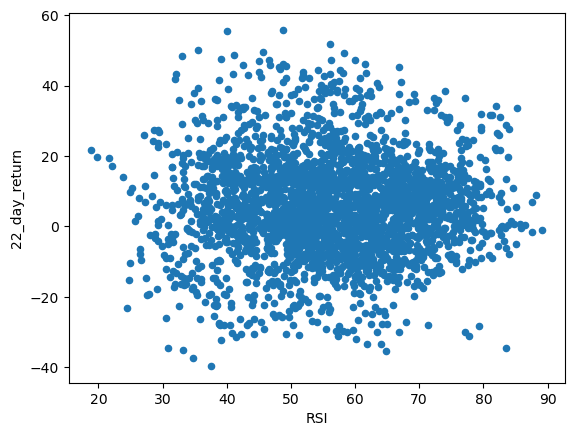

In [194]:
ndf.plot(kind='scatter', x='RSI', y='22_day_return')

<Axes: xlabel='20_EMA', ylabel='5_day_return'>

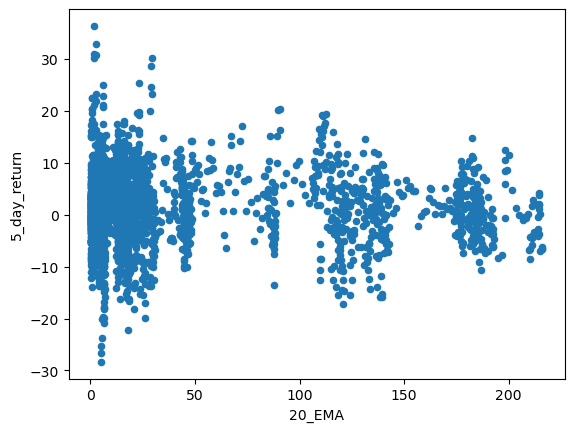

In [195]:
ndf.plot(kind='scatter', x='20_EMA', y='5_day_return')

In [196]:
ndf.columns

Index(['Ticker', 'Close', 'High', 'Low', 'Open', 'Volume', 'Bullish/Bearish',
       'confirmed_trend', 'Harami', 'Harami_cross', 'Body %', 'Upper_wick',
       'Upper_wick_percentage', 'Lower_wick', 'Lower_wick_percentage',
       'Wick_to_body_ratio', 'RSI', 'gap_size', 'gap_percentage', '5_EMA',
       '10_EMA', '20_EMA', '50_EMA', '200_EMA', 'EMA_Alignment',
       '5EMA_touched', '10EMA_touched', '20EMA_touched', '50EMA_touched',
       '200EMA_touched', '5EMA_days_since_touch', '10EMA_days_since_touch',
       '20EMA_days_since_touch', '5_day_return', '10_day_return',
       '15_day_return', '22_day_return', '6_month_return', '1_year_return',
       '5_year_return', 'Candle_Body', 'Candle_Range', 'Close_to_5EMA_pct',
       'Close_to_10EMA_pct', 'Close_to_20EMA_pct', 'Close_to_50EMA_pct',
       'Close_to_200EMA_pct', 'positive_22_day_return'],
      dtype='object')

<Axes: xlabel='Close_to_20EMA_pct', ylabel='22_day_return'>

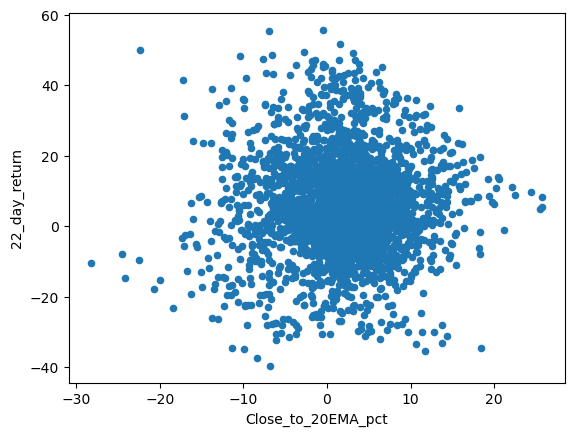

In [197]:
ndf.plot(kind='scatter', x="Close_to_20EMA_pct", y='22_day_return')

<Axes: xlabel='Body %', ylabel='5_day_return'>

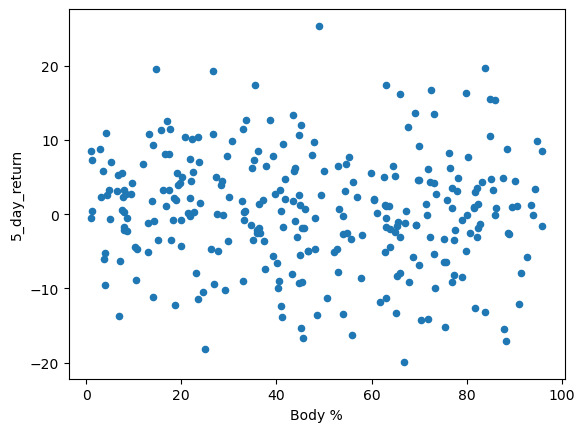

In [198]:
ndf_sl.plot(kind='scatter', x='Body %', y='5_day_return')

In [233]:
ndf

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Candle_Body,Candle_Range,Close_to_5EMA_pct,Close_to_10EMA_pct,Close_to_20EMA_pct,Close_to_50EMA_pct,Close_to_200EMA_pct,positive_22_day_return,positive_22_day_return_num,Month,Year,Month_Name
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482985,0.486584,0.475307,0.482985,113680000,Doji,0,0,0,0.000000,0.003599,31.915002,0.007678,68.084998,inf,NaN,NaN,NaN,0.482985,0.482985,0.482985,0.482985,0.482985,divergence,True,True,True,True,True,0,0,0,-0.943880,-0.844511,2.434196,0.149022,2.302580,66.451436,1120.554109,0.000000,0.011277,0.000000,0.000000,0.000000,0.000000,0.000000,True,1,1,2015,January
2015-01-05,NVDA,0.474827,0.484425,0.472668,0.482985,197952000,Bearish,0,0,0,69.387800,0.001440,12.244977,0.002159,18.367223,0.441176,NaN,-5.664483e-08,-0.000012,0.480266,0.481502,0.482208,0.482665,0.482904,Bearish,True,True,True,True,True,0,0,0,-0.505286,1.162204,-0.808457,3.537151,2.786199,66.280449,1117.675469,0.008158,0.011757,-1.132399,-1.386195,-1.530637,-1.623874,-1.672510,True,1,1,2015,January
2015-01-06,NVDA,0.460432,0.476027,0.459952,0.475547,197764000,Bearish,0,0,0,94.029920,0.000480,2.985040,0.000480,2.985040,0.063491,NaN,7.198833e-04,0.151609,0.473655,0.477671,0.480134,0.481793,0.482681,Bearish,True,False,False,False,False,0,1,1,2.449163,5.784263,0.625340,6.305373,4.002881,74.234049,1171.855199,0.015116,0.016075,-2.791686,-3.609065,-4.103596,-4.433820,-4.609447,True,1,1,2015,January
2015-01-07,NVDA,0.459232,0.467870,0.457792,0.463791,321808000,Bearish,0,0,0,45.237879,0.004079,40.476326,0.001440,14.285795,1.210537,NaN,3.359050e-03,0.729544,0.468847,0.474318,0.478144,0.480909,0.482447,Bearish,False,False,False,False,False,1,2,2,3.134795,7.889194,3.343787,6.478550,3.536956,67.465837,1200.160897,0.004559,0.010077,-2.050791,-3.180680,-3.955240,-4.507457,-4.811977,True,1,1,2015,January
2015-01-08,NVDA,0.476507,0.479386,0.464270,0.464510,283780000,Bullish,0,0,0,79.364899,0.002879,19.047727,0.000240,1.587374,0.260003,NaN,5.278483e-03,1.149415,0.471400,0.474716,0.477988,0.480736,0.482388,Bearish,True,True,True,False,False,0,0,0,-1.309131,4.279932,-3.323276,5.488424,-1.435406,54.996084,1132.969423,0.011997,0.015116,1.083305,0.377204,-0.309785,-0.879696,-1.219146,True,1,1,2015,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,-1,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.494618,-2.620010e+00,-1.338516,198.058194,201.816238,205.671428,205.461208,188.614068,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002,-2.791197,-4.601334,-6.389526,-6.293747,2.076161,False,0,6,2026,June
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,1,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.084358,1.320007e+00,0.685611,197.028796,200.571468,204.652244,205.049789,188.677311,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119995,6.379990,-1.044921,-2.792753,-4.731071,-4.915776,3.335160,False,0,6,2026,June
2026-06-30,NVDA,200.089996,200.630005,195.110001,197.240005,166476700,Bullish,1,0,0,51.630229,0.540009,9.782756,2.130005,38.587015,0.936850,45.213841,2.270004e+00,1.164284,198.049196,200.483927,204.217745,204.855287,188.790870,divergence,True,True,False,False,False,0,0,6,Na

<Axes: xlabel='gap_size', ylabel='22_day_return'>

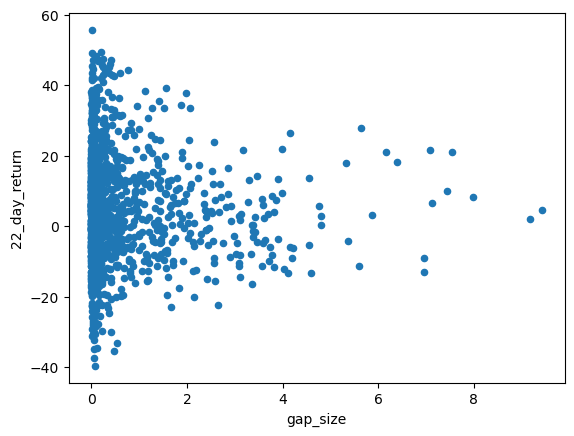

In [235]:
ndf_pos.plot(kind='scatter', x='gap_size', y='22_day_return')

In [200]:
ndf[["Harami", "5_day_return"]].corr()

,Harami,5_day_return
Harami,1.000000,0.019015
5_day_return,0.019015,1.000000


In [201]:
ndf[["Harami", "10_day_return"]].corr()

,Harami,10_day_return
Harami,1.000000,0.028973
10_day_return,0.028973,1.000000


In [202]:
ndf[["Harami", "22_day_return"]].corr()

,Harami,22_day_return
Harami,1.000000,0.028038
22_day_return,0.028038,1.000000


In [203]:
ndf.groupby("Harami")["5_day_return"].mean()

Harami
-100   -0.045186
 0      1.327549
 100    0.906800
Name: 5_day_return, dtype: float64

In [204]:
ndf.groupby("Harami")["10_day_return"].mean()

Harami
-100    0.248652
 0      2.642964
 100    2.271840
Name: 10_day_return, dtype: float64

In [205]:
ndf.groupby("Harami")["22_day_return"].mean()

Harami
-100    2.953626
 0      5.802775
 100    5.869680
Name: 22_day_return, dtype: float64

In [206]:
ndf.groupby("Harami")["5_day_return"].count()

Harami
-100     107
 0      2664
 100     115
Name: 5_day_return, dtype: int64

In [207]:
ndf.groupby("Harami")["positive_22_day_return"].mean()

Harami
-100    0.504673
 0      0.661671
 100    0.721739
Name: positive_22_day_return, dtype: float64

In [208]:
ndf["positive_22_day_return_num"] = ndf["positive_22_day_return"].astype(int)
ndf

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Candle_Body,Candle_Range,Close_to_5EMA_pct,Close_to_10EMA_pct,Close_to_20EMA_pct,Close_to_50EMA_pct,Close_to_200EMA_pct,positive_22_day_return,positive_22_day_return_num
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482985,0.486584,0.475307,0.482985,113680000,Doji,0,0,0,0.000000,0.003599,31.915002,0.007678,68.084998,inf,NaN,NaN,NaN,0.482985,0.482985,0.482985,0.482985,0.482985,divergence,True,True,True,True,True,0,0,0,-0.943880,-0.844511,2.434196,0.149022,2.302580,66.451436,1120.554109,0.000000,0.011277,0.000000,0.000000,0.000000,0.000000,0.000000,True,1
2015-01-05,NVDA,0.474827,0.484425,0.472668,0.482985,197952000,Bearish,0,0,0,69.387800,0.001440,12.244977,0.002159,18.367223,0.441176,NaN,-5.664483e-08,-0.000012,0.480266,0.481502,0.482208,0.482665,0.482904,Bearish,True,True,True,True,True,0,0,0,-0.505286,1.162204,-0.808457,3.537151,2.786199,66.280449,1117.675469,0.008158,0.011757,-1.132399,-1.386195,-1.530637,-1.623874,-1.672510,True,1
2015-01-06,NVDA,0.460432,0.476027,0.459952,0.475547,197764000,Bearish,0,0,0,94.029920,0.000480,2.985040,0.000480,2.985040,0.063491,NaN,7.198833e-04,0.151609,0.473655,0.477671,0.480134,0.481793,0.482681,Bearish,True,False,False,False,False,0,1,1,2.449163,5.784263,0.625340,6.305373,4.002881,74.234049,1171.855199,0.015116,0.016075,-2.791686,-3.609065,-4.103596,-4.433820,-4.609447,True,1
2015-01-07,NVDA,0.459232,0.467870,0.457792,0.463791,321808000,Bearish,0,0,0,45.237879,0.004079,40.476326,0.001440,14.285795,1.210537,NaN,3.359050e-03,0.729544,0.468847,0.474318,0.478144,0.480909,0.482447,Bearish,False,False,False,False,False,1,2,2,3.134795,7.889194,3.343787,6.478550,3.536956,67.465837,1200.160897,0.004559,0.010077,-2.050791,-3.180680,-3.955240,-4.507457,-4.811977,True,1
2015-01-08,NVDA,0.476507,0.479386,0.464270,0.464510,283780000,Bullish,0,0,0,79.364899,0.002879,19.047727,0.000240,1.587374,0.260003,NaN,5.278483e-03,1.149415,0.471400,0.474716,0.477988,0.480736,0.482388,Bearish,True,True,True,False,False,0,0,0,-1.309131,4.279932,-3.323276,5.488424,-1.435406,54.996084,1132.969423,0.011997,0.015116,1.083305,0.377204,-0.309785,-0.879696,-1.219146,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,-1,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.494618,-2.620010e+00,-1.338516,198.058194,201.816238,205.671428,205.461208,188.614068,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002,-2.791197,-4.601334,-6.389526,-6.293747,2.076161,False,0
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,1,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.084358,1.320007e+00,0.685611,197.028796,200.571468,204.652244,205.049789,188.677311,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119995,6.379990,-1.044921,-2.792753,-4.731071,-4.915776,3.335160,False,0
2026-06-30,NVDA,200.089996,200.630005,195.110001,197.240005,166476700,Bullish,1,0,0,51.630229,0.540009,9.782756,2.130005,38.587015,0.936850,45.213841,2.270004e+00,1.164284,198.049196,200.483927,204.217745,204.855287,188.790870,divergence,True,True,False,False,False,0,0,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.849991,5.520004,1.030451,-0.196490,-2.021249,-2.326174,5.984996,False,0


In [16]:
ndf_20 = ndf[ndf['20EMA_days_since_touch'] > 60]
ndf_20

,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Candle_Body,Candle_Range,positive_22_day_return,positive_22_day_return_num,Month,Year,Month_Name
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-01-04,NVDA,3.376240,3.414417,3.215348,3.246089,585620000,Bullish,1,0,0,65.379938,0.038177,19.178011,0.030740,15.442051,0.529521,41.374368,0.073133,2.304883,3.309440,3.344199,3.505511,4.143666,5.221605,Bearish,True,True,False,False,False,0,0,61,9.281161,15.228703,1.336363,12.343055,17.907473,74.015675,1365.883594,0.130151,0.199069,True,1,1,2019,January
2025-07-29,NVDA,175.480835,179.350202,174.990926,177.930440,154077500,Bearish,1,0,0,56.192933,1.419762,32.568761,0.489909,11.238307,0.779583,71.064333,1.209813,0.684591,174.177625,171.920511,166.923901,153.730620,132.104056,Bullish,False,False,False,False,False,4,4,61,1.566862,4.358725,0.074068,2.655119,7.424720,NaN,NaN,2.449605,4.359276,True,1,7,2025,July
2025-07-30,NVDA,179.240219,179.860111,176.010745,176.480668,174312200,Bullish,1,0,0,71.688452,0.619892,16.103744,0.469923,12.207805,0.394925,74.425354,0.999833,0.569768,175.865156,173.251367,168.096884,154.730996,132.573073,Bullish,False,False,False,False,False,5,5,62,0.083666,1.294135,-2.158762,-2.839303,6.845241,NaN,NaN,2.759551,3.849366,False,0,7,2025,July
2025-07-31,NVDA,177.840439,183.269544,175.900759,182.869602,221685400,Bearish,1,0,0,68.249548,0.399943,5.427525,1.939680,26.322927,0.465211,71.113162,3.629383,2.024871,176.523584,174.085744,169.024842,155.637249,133.023494,Bullish,True,False,False,False,False,0,6,63,1.630414,2.333163,-1.624786,-3.986057,8.242857,NaN,NaN,5.029163,7.368786,False,0,7,2025,July
2025-08-01,NVDA,173.691132,176.510655,170.861600,174.061065,204529000,Bearish,1,0,0,6.548593,2.449590,43.362825,2.829532,50.088582,14.270455,62.267034,-3.779374,-2.125149,175.579433,174.013996,169.469250,156.345244,133.428148,Bullish,True,True,False,False,False,0,0,64,5.169234,3.874050,2.457985,-1.784473,10.034207,NaN,NaN,0.369934,5.649055,False,0,8,2025,August
2025-08-04,NVDA,179.970093,180.170056,174.491008,175.130901,148174600,Bullish,1,0,0,85.211313,0.199964,3.521078,0.639893,11.267609,0.173553,68.627017,1.439769,0.828925,177.042986,175.096923,170.469330,157.271709,133.891251,Bullish,True,True,False,False,False,0,0,65,1.144438,1.116663,-0.105557,-4.633330,3.128224,NaN,NaN,4.839192,5.679049,False,0,8,2025,August
2025-08-05,NVDA,178.230377,180.230045,175.870769,179.590152,156407600,Bearish,1,-100,0,31.192670,0.639893,14.678883,2.359609,54.128447,2.205881,65.340812,-0.379941,-0.211113,177.438783,175.666642,171.208478,158.093618,134.332437,Bullish,True,False,False,False,False,0,1,66,2.748794,-1.469765,1.969033,-6.305386,1.178168,NaN,NaN,1.359775,4.359276,False,0,8,2025,August
2025-08-06,NVDA,179.390182,179.870098,176.220711,176.300700,137192300,Bullish,1,0,0,84.657575,0.479916,13.150590,0.079989,2.191835,0.181229,66.492752,-1.929678,-1.082687,178.089250,176.343649,171.987688,158.928777,134.780773,Bullish,True,True,False,False,False,0,0,67,1.209457,-2.240553,1.215028,-6.192175,-2.904066,NaN,NaN,3.089483,3.649387,False,0,8,2025,August
2025-08-07,NVDA,180.739975,183.849459,178.770301,181.539845,151878400,Bearish,1,0,0,15.748086,2.309614,45.472376,1.969674,38.779538,5.349978,67.832713,2.149663,1.198317,178.972825,177.142981,172.821239,159.784118,135.238078,Bullish,True,False,False,False,False,0,1,68,0.691475,-3.202978,-0.331921,-5.537437,-4.907203,NaN,NaN,0.799870,5.079158,False,0,8,2025,August


In [209]:
lr_harami_return = smf.ols('positive_22_day_return_num ~ Harami', data=ndf).fit()

In [210]:
lr_harami_return.params

Intercept    0.657954
Harami       0.001069
dtype: float64

In [211]:
lr_harami_return.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                                
======================================================================================
Dep. Variable:     positive_22_day_return_num   R-squared:                       0.004
Model:                                    OLS   Adj. R-squared:                  0.004
Method:                         Least Squares   F-statistic:                     11.32
Date:                        Thu, 09 Jul 2026   Prob (F-statistic):           0.000778
Time:                                15:38:49   Log-Likelihood:                -1940.0
No. Observations:                        2891   AIC:                             3884.
Df Residuals:                            2889   BIC:                             3896.
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6580      0.009     74.704      0.000       0.641       0.675
Harami         0.0011      0.000      3.364      0.001       0.000       0.002
==============================================================================
Omnibus:                    16770.878   Durbin-Watson:                   0.384
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              499.031
Skew:                          -0.664   Prob(JB):                    4.33e-109
Kurtosis:                       1.458   Cond. No.                         27.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [212]:
lr_rsi_return = smf.ols('positive_22_day_return_num ~ Harami + EMA_Alignment + RSI', data=ndf).fit()

In [213]:
lr_rsi_return.params

Intercept                      0.506293
EMA_Alignment[T.Bullish]      -0.109193
EMA_Alignment[T.divergence]   -0.043843
Harami                         0.001155
RSI                            0.003978
dtype: float64

In [214]:
lr_rsi_return.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                                
======================================================================================
Dep. Variable:     positive_22_day_return_num   R-squared:                       0.009
Model:                                    OLS   Adj. R-squared:                  0.007
Method:                         Least Squares   F-statistic:                     6.358
Date:                        Thu, 09 Jul 2026   Prob (F-statistic):           4.32e-05
Time:                                15:38:51   Log-Likelihood:                -1926.9
No. Observations:                        2877   AIC:                             3864.
Df Residuals:                            2872   BIC:                             3894.
Df Model:                                   4                                         
Covariance Type:                    nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       0.5063      0.053      9.471      0.000       0.401       0.611
EMA_Alignment[T.Bullish]       -0.1092      0.049     -2.247      0.025      -0.204      -0.014
EMA_Alignment[T.divergence]    -0.0438      0.041     -1.079      0.281      -0.124       0.036
Harami                          0.0012      0.000      3.619      0.000       0.001       0.002
RSI                             0.0040      0.001      3.752      0.000       0.002       0.006
==============================================================================
Omnibus:                    16950.532   Durbin-Watson:                   0.397
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              487.059
Skew:                          -0.653   Prob(JB):                    1.72e-106
Kurtosis:                       1.465   Cond. No.                         418.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [215]:
lr_trend = smf.ols('positive_22_day_return_num ~ confirmed_trend', data=ndf).fit()

In [216]:
lr_trend.params

Intercept          0.732374
confirmed_trend   -0.082137
dtype: float64

In [217]:
lr_trd = smf.ols("Q('22_day_return') ~ C(confirmed_trend)", data=ndf).fit()

In [218]:
lr_trd.params

Intercept                  9.290644
C(confirmed_trend)[T.0]   -0.108465
C(confirmed_trend)[T.1]   -3.854355
dtype: float64

In [219]:
lr_trd.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     Q('22_day_return')   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     6.784
Date:                Thu, 09 Jul 2026   Prob (F-statistic):            0.00115
Time:                        15:41:59   Log-Likelihood:                -11642.
No. Observations:                2869   AIC:                         2.329e+04
Df Residuals:                    2866   BIC:                         2.331e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   9.2906      1.556      5.971      0.000       6.240      12.342
C(confirmed_trend)[T.0]    -0.1085      2.021     -0.054      0.957      -4.071       3.854
C(confirmed_trend)[T.1]    -3.8544      1.579     -2.440      0.015      -6.951      -0.757
==============================================================================
Omnibus:                       46.291   Durbin-Watson:                   0.108
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               61.667
Skew:                           0.208   Prob(JB):                     4.07e-14
Kurtosis:                       3.586   Cond. No.                         14.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [232]:
ndf.to_csv('NVDA.csv', index=True, index_label='Date')